In [1]:
import glob
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import cohen_kappa_score, f1_score
from tabulate import tabulate

score_order = ["Wake", "N1", "N2", "N3", "REM"]

In [2]:
reprod_results_paths = [
    "../../logs/exp001/exp001a/sweep-2025-07-30_12-29-20_test_eval/0/usleep_test_results.json",
    "../../logs/exp001/exp001a/sweep-2025-07-30_12-29-20_test_eval/1/usleep_test_results.json",
    "../../logs/exp001/exp001a/sweep-2025-07-30_12-29-20_test_eval/2/usleep_test_results.json",
    "../../logs/exp002/exp002a/sweep-2025-07-29_14-59-03_test_eval/1/anysleep_test_results.json",
    "../../logs/exp002/exp002a/sweep-2025-07-29_14-59-03_test_eval/2/anysleep_test_results.json",
    "../../logs/exp002/exp002a/sweep-2025-07-29_14-59-03_test_eval/3/anysleep_test_results.json",
]

dataset_f1s = {}
for reprod_results_path in reprod_results_paths:
    with open(reprod_results_path, "r") as f:
        reprod_results = json.load(f)

    for dataset, results in reprod_results["datasets"].items():
        f1s = {}
        for channel, scores in results.items():
            f1s[channel] = [scores[score]["f1"][0] for score in score_order]
            f1s[channel].append(np.mean(f1s[channel]))

        if dataset not in dataset_f1s:
            dataset_f1s[dataset] = []
        dataset_f1s[dataset].append(f1s['majority'] if "majority" in f1s else f1s['concat'])

in_sample_datasets = ["abc", "ccshs", "cfs", "chat", "dcsm", "hpap", "mesa", "mros", "phys", "sedf-sc", "sedf-st",
                      "shhs", "sof"]
ood_datasets = ["dodh", "dodo", "isruc-sg1", "isruc-sg2", "isruc-sg3", "mass-c1", "mass-c3", "svuh"]
assert all([(ds in in_sample_datasets or ds in ood_datasets) for ds in
            dataset_f1s.keys()]), f"Dataset not found: {set(dataset_f1s.keys()).difference(in_sample_datasets + ood_datasets)}"

In [3]:
# load hypnograms with test predictions and GT
hyp_path_usleep = "../../logs/exp001/exp001a/sweep-2026-03-02_12-29-30_test_predictions"
hyp_path_anysleep = "../../logs/exp002/exp002a/sweep-2026-03-02_12-24-46_test_predictions"

hyp_gt_usleep = {}
hyp_pred_usleep = {}
hyp_gt_anysleep = {}
hyp_pred_anysleep = {}

for run_dir in os.listdir(hyp_path_usleep):
    if not re.match("\d", run_dir):
        continue
    run_dir_base = os.path.join(hyp_path_usleep, run_dir)
    with open(os.path.join(run_dir_base, "predict-high-freq.log")) as f:
        lines = f.readlines()
        sr_line = [line for line in lines if "sleep_stage_frequency" in line][0]
        sleep_stage_sr = int(sr_line.split("=")[1])
        if sleep_stage_sr > 1:
            continue
        model_line = [line for line in lines if "model.path" in line][0]
        model = model_line.split("=")[1]

    hyp_gt_usleep[model] = np.load(os.path.join(run_dir_base, "labels.npz"))
    hyp_pred_usleep[model] = np.load(os.path.join(run_dir_base, "predictions.npz"))

for run_dir in os.listdir(hyp_path_anysleep):
    if not re.match("\d", run_dir):
        continue
    run_dir_base = os.path.join(hyp_path_anysleep, run_dir)
    with open(os.path.join(run_dir_base, "predict-high-freq.log")) as f:
        lines = f.readlines()
        sr_line = [line for line in lines if "sleep_stage_frequency" in line][0]
        sleep_stage_sr = int(sr_line.split("=")[1])
        if sleep_stage_sr > 1:
            continue
        model_line = [line for line in lines if "model.path" in line][0]
        model = model_line.split("=")[1]

    hyp_gt_anysleep[model] = np.load(os.path.join(run_dir_base, "labels.npz"))
    hyp_pred_anysleep[model] = np.load(os.path.join(run_dir_base, "predictions.npz"))

In [4]:
hyp_total_gt_usleep = {}
hyp_total_pred_usleep = {}
hyp_total_gt_anysleep = {}
hyp_total_pred_anysleep = {}

for model in hyp_gt_usleep.keys():
    hyp_total_gt_usleep[model] = {}
    hyp_total_pred_usleep[model] = {}
    for s_id in hyp_gt_usleep[model].keys():
        dataset = s_id.split("_")[0]
        if dataset not in hyp_total_gt_usleep[model]:
            hyp_total_gt_usleep[model][dataset] = []
            hyp_total_pred_usleep[model][dataset] = []
        hyp_total_gt_usleep[model][dataset].append(hyp_gt_usleep[model][s_id])
        hyp_total_pred_usleep[model][dataset].append(hyp_pred_usleep[model][s_id])

hyp_total_gt_usleep = {model: {ds: np.concat(hyp_total_gt_usleep[model][ds])
                               for ds in hyp_total_gt_usleep[model]}
                       for model in hyp_total_gt_usleep}
hyp_total_pred_usleep = {model: {ds: np.concat(hyp_total_pred_usleep[model][ds])
                                 for ds in hyp_total_pred_usleep[model]}
                         for model in hyp_total_pred_usleep}

for model in hyp_gt_anysleep.keys():
    hyp_total_gt_anysleep[model] = {}
    hyp_total_pred_anysleep[model] = {}
    for s_id in hyp_gt_anysleep[model].keys():
        dataset = s_id.split("_")[0]
        if dataset not in hyp_total_gt_anysleep[model]:
            hyp_total_gt_anysleep[model][dataset] = []
            hyp_total_pred_anysleep[model][dataset] = []
        hyp_total_gt_anysleep[model][dataset].append(hyp_gt_anysleep[model][s_id])
        hyp_total_pred_anysleep[model][dataset].append(hyp_pred_anysleep[model][s_id])

hyp_total_gt_anysleep = {model: {ds: np.concat(hyp_total_gt_anysleep[model][ds])
                                 for ds in hyp_total_gt_anysleep[model]}
                         for model in hyp_total_gt_anysleep}
hyp_total_pred_anysleep = {model: {ds: np.concat(hyp_total_pred_anysleep[model][ds])
                                   for ds in hyp_total_pred_anysleep[model]}
                           for model in hyp_total_pred_anysleep}

cohks_usleep = {}
for model in hyp_total_gt_usleep.keys():
    cohks_usleep[model] = {}
    for ds in hyp_total_gt_usleep[model].keys():
        art_mask = hyp_total_gt_usleep[model][ds] == 9
        cohk = cohen_kappa_score(hyp_total_gt_usleep[model][ds][~art_mask], hyp_total_pred_usleep[model][ds][~art_mask],
                                 labels=range(5))
        cohks_usleep[model][ds] = cohk

cohks_anysleep = {}
for model in hyp_total_gt_anysleep.keys():
    cohks_anysleep[model] = {}
    for ds in hyp_total_gt_anysleep[model].keys():
        art_mask = hyp_total_gt_anysleep[model][ds] == 9
        cohk = cohen_kappa_score(hyp_total_gt_anysleep[model][ds][~art_mask],
                                 hyp_total_pred_anysleep[model][ds][~art_mask],
                                 labels=range(5))
        cohks_anysleep[model][ds] = cohk

## AnySleep

In [5]:
# present scores as table
# values from datasplit (see config/usleep_split.yaml)
n_recordings = [20, 78, 92, 128, 39, 36, 100, 134, 100, 23, 8, 140, 68, 25, 55, 100, 16, 10, 53, 62, 25]
table_data = np.empty((len(in_sample_datasets) + len(ood_datasets) + 2, len(score_order) + 4), dtype=object)
col_means = np.zeros(len(score_order) + 2)
for ds_i, dataset in enumerate(in_sample_datasets):
    f1s = dataset_f1s[dataset][3:]
    means = np.mean(f1s, axis=0)
    stds = np.std(f1s, axis=0)
    table_data[ds_i, 2:-1] = [f"{m:.2f} ({s:.3f})" for m, s in zip(means, stds)]

    cks = [cohks_anysleep[m][dataset] for m in cohks_anysleep.keys()]
    table_data[ds_i, -1] = f"{np.mean(cks):.2f} ({np.std(cks):.3f})"

    col_means += (means * n_recordings[ds_i]).tolist() + [np.mean(cks) * n_recordings[ds_i]]

# add mean over all datasets
col_means = col_means / np.sum(n_recordings[:len(in_sample_datasets)])
table_data[len(in_sample_datasets), 2:] = [f"{col_means[i]:.3f}" for i in range(len(col_means))]

col_means = np.zeros(len(score_order) + 2)
for ds_i, dataset in enumerate(ood_datasets, len(in_sample_datasets) + 1):
    f1s = dataset_f1s[dataset][3:]
    means = np.mean(f1s, axis=0)
    stds = np.std(f1s, axis=0)
    table_data[ds_i, 2:-1] = [f"{m:.2f} ({s:.3f})" for m, s in zip(means, stds)]

    cks = [cohks_anysleep[m][dataset] for m in cohks_anysleep.keys()]
    table_data[ds_i, -1] = f"{np.mean(cks):.2f} ({np.std(cks):.3f})"

    col_means += (means * n_recordings[ds_i - 1]).tolist() + [np.mean(cks) * n_recordings[ds_i - 1]]

# add mean over all datasets
col_means = col_means / np.sum(n_recordings[len(in_sample_datasets):])
table_data[len(in_sample_datasets) + len(ood_datasets) + 1, 2:] = [f"{col_means[i]:.3f}" for i in
                                                                   range(len(col_means))]

table_data[:, 0] = in_sample_datasets + ["Mean"] + ood_datasets + ["Mean"]
table_data[:, 1] = n_recordings[:len(in_sample_datasets)] + [""] + n_recordings[len(in_sample_datasets):] + [""]
table_data[:, 1] = [str(t) for t in table_data[:, 1]]

In [6]:
# add a midrule between in-distribution and out-of-distribution
table_data = table_data.tolist()
table_data.insert(len(in_sample_datasets) + 1, [""] * len(table_data[0]))
table_data.insert(len(in_sample_datasets) + len(ood_datasets) + 3, [""] * len(table_data[0]))

tabulate(table_data,
         headers=["", ""] + score_order + ["MF1", "Cohen's Kappa"],
         tablefmt="unsafehtml")

,,Wake,N1,N2,N3,REM,MF1,Cohen's Kappa
abc,20,0.90 (0.003),0.60 (0.012),0.84 (0.003),0.76 (0.018),0.91 (0.003),0.80 (0.006),0.77 (0.005)
ccshs,78,0.97 (0.001),0.64 (0.003),0.92 (0.000),0.89 (0.001),0.93 (0.001),0.87 (0.001),0.89 (0.001)
cfs,92,0.96 (0.001),0.52 (0.004),0.89 (0.000),0.85 (0.000),0.91 (0.001),0.83 (0.001),0.86 (0.001)
chat,128,0.96 (0.001),0.65 (0.004),0.87 (0.001),0.91 (0.000),0.91 (0.002),0.86 (0.001),0.86 (0.001)
dcsm,39,0.98 (0.005),0.52 (0.008),0.85 (0.000),0.82 (0.002),0.87 (0.028),0.81 (0.005),0.85 (0.009)
hpap,36,0.92 (0.002),0.51 (0.031),0.84 (0.004),0.77 (0.006),0.90 (0.002),0.79 (0.006),0.77 (0.002)
mesa,100,0.95 (0.001),0.57 (0.006),0.86 (0.001),0.69 (0.003),0.91 (0.001),0.80 (0.001),0.82 (0.001)
mros,134,0.96 (0.000),0.45 (0.006),0.87 (0.002),0.71 (0.002),0.89 (0.001),0.78 (0.001),0.83 (0.001)
phys,100,0.84 (0.006),0.61 (0.010),0.84 (0.002),0.81 (0.002),0.88 (0.002),0.79 (0.002),0.74 (0.001)
sedf-sc,23,0.99 (0.000),0.58 (0.005),0.87 (0.002),0.73 (0.017),0.87 (0.015),0.81 (0.004),0.86 (0.002)


In [7]:
print(tabulate(table_data,
               headers=["", ""] + score_order + ["MF1", "Cohen's Kappa"],
               tablefmt="latex_raw"))

\begin{tabular}{lllllllll}
\hline
           &     & Wake         & N1           & N2           & N3           & REM          & MF1          & Cohen's Kappa   \\
\hline
 abc       & 20  & 0.90 (0.003) & 0.60 (0.012) & 0.84 (0.003) & 0.76 (0.018) & 0.91 (0.003) & 0.80 (0.006) & 0.77 (0.005)    \\
 ccshs     & 78  & 0.97 (0.001) & 0.64 (0.003) & 0.92 (0.000) & 0.89 (0.001) & 0.93 (0.001) & 0.87 (0.001) & 0.89 (0.001)    \\
 cfs       & 92  & 0.96 (0.001) & 0.52 (0.004) & 0.89 (0.000) & 0.85 (0.000) & 0.91 (0.001) & 0.83 (0.001) & 0.86 (0.001)    \\
 chat      & 128 & 0.96 (0.001) & 0.65 (0.004) & 0.87 (0.001) & 0.91 (0.000) & 0.91 (0.002) & 0.86 (0.001) & 0.86 (0.001)    \\
 dcsm      & 39  & 0.98 (0.005) & 0.52 (0.008) & 0.85 (0.000) & 0.82 (0.002) & 0.87 (0.028) & 0.81 (0.005) & 0.85 (0.009)    \\
 hpap      & 36  & 0.92 (0.002) & 0.51 (0.031) & 0.84 (0.004) & 0.77 (0.006) & 0.90 (0.002) & 0.79 (0.006) & 0.77 (0.002)    \\
 mesa      & 100 & 0.95 (0.001) & 0.57 (0.006) & 0.86 (0.001) &

## U-Sleep

In [8]:
# present scores as table
table_data = np.empty((len(in_sample_datasets) + len(ood_datasets) + 2, len(score_order) + 4), dtype=object)
col_means = np.zeros(len(score_order) + 2)
for ds_i, dataset in enumerate(in_sample_datasets):
    f1s = dataset_f1s[dataset][:3]
    means = np.mean(f1s, axis=0)
    stds = np.std(f1s, axis=0)
    table_data[ds_i, 2:-1] = [f"{m:.2f} ({s:.3f})" for m, s in zip(means, stds)]

    cks = [cohks_usleep[m][dataset] for m in cohks_usleep.keys()]
    table_data[ds_i, -1] = f"{np.mean(cks):.2f} ({np.std(cks):.3f})"

    col_means += (means * n_recordings[ds_i]).tolist() + [np.mean(cks) * n_recordings[ds_i]]

# add mean over all datasets
col_means = col_means / np.sum(n_recordings[:len(in_sample_datasets)])
table_data[len(in_sample_datasets), 2:] = [f"{col_means[i]:.3f}" for i in range(len(col_means))]

col_means = np.zeros(len(score_order) + 2)
for ds_i, dataset in enumerate(ood_datasets, len(in_sample_datasets) + 1):
    f1s = dataset_f1s[dataset][:3]
    means = np.mean(f1s, axis=0)
    stds = np.std(f1s, axis=0)
    table_data[ds_i, 2:-1] = [f"{m:.2f} ({s:.3f})" for m, s in zip(means, stds)]

    cks = [cohks_usleep[m][dataset] for m in cohks_usleep.keys()]
    table_data[ds_i, -1] = f"{np.mean(cks):.2f} ({np.std(cks):.3f})"

    col_means += (means * n_recordings[ds_i - 1]).tolist() + [np.mean(cks) * n_recordings[ds_i - 1]]

# add mean over all datasets
col_means = col_means / np.sum(n_recordings[len(in_sample_datasets):])
table_data[len(in_sample_datasets) + len(ood_datasets) + 1, 2:] = [f"{col_means[i]:.3f}" for i in
                                                                   range(len(col_means))]

table_data[:, 0] = in_sample_datasets + ["Mean"] + ood_datasets + ["Mean"]
table_data[:, 1] = n_recordings[:len(in_sample_datasets)] + [""] + n_recordings[len(in_sample_datasets):] + [""]
table_data[:, 1] = [str(t) for t in table_data[:, 1]]

In [9]:
# add a midrule between in-distribution and out-of-distribution
table_data = table_data.tolist()
table_data.insert(len(in_sample_datasets) + 1, [""] * len(table_data[0]))
table_data.insert(len(in_sample_datasets) + len(ood_datasets) + 3, [""] * len(table_data[0]))

tabulate(table_data,
         headers=["", ""] + score_order + ["MF1", "Cohen's Kappa"],
         tablefmt="unsafehtml")

,,Wake,N1,N2,N3,REM,MF1,Cohen's Kappa
abc,20,0.88 (0.007),0.53 (0.022),0.83 (0.002),0.68 (0.035),0.89 (0.009),0.76 (0.009),0.74 (0.008)
ccshs,78,0.97 (0.001),0.61 (0.008),0.91 (0.002),0.88 (0.001),0.92 (0.003),0.86 (0.003),0.88 (0.003)
cfs,92,0.96 (0.002),0.51 (0.007),0.88 (0.002),0.84 (0.004),0.90 (0.006),0.82 (0.004),0.85 (0.003)
chat,128,0.96 (0.003),0.60 (0.023),0.86 (0.004),0.90 (0.001),0.89 (0.009),0.84 (0.007),0.84 (0.006)
dcsm,39,0.98 (0.001),0.50 (0.016),0.85 (0.003),0.80 (0.011),0.89 (0.009),0.81 (0.005),0.86 (0.004)
hpap,36,0.91 (0.002),0.43 (0.009),0.84 (0.003),0.77 (0.003),0.90 (0.004),0.77 (0.002),0.76 (0.002)
mesa,100,0.95 (0.001),0.53 (0.024),0.86 (0.001),0.69 (0.008),0.90 (0.002),0.78 (0.006),0.81 (0.003)
mros,134,0.95 (0.002),0.43 (0.011),0.86 (0.004),0.69 (0.013),0.88 (0.005),0.76 (0.007),0.82 (0.005)
phys,100,0.84 (0.004),0.57 (0.017),0.84 (0.003),0.81 (0.001),0.88 (0.002),0.79 (0.005),0.74 (0.004)
sedf-sc,23,0.98 (0.001),0.56 (0.011),0.86 (0.003),0.75 (0.006),0.86 (0.004),0.80 (0.003),0.84 (0.002)


In [10]:
print(tabulate(table_data,
               headers=["", ""] + score_order + ["MF1", "Cohen's Kappa"],
               tablefmt="latex_raw"))

\begin{tabular}{lllllllll}
\hline
           &     & Wake         & N1           & N2           & N3           & REM          & MF1          & Cohen's Kappa   \\
\hline
 abc       & 20  & 0.88 (0.007) & 0.53 (0.022) & 0.83 (0.002) & 0.68 (0.035) & 0.89 (0.009) & 0.76 (0.009) & 0.74 (0.008)    \\
 ccshs     & 78  & 0.97 (0.001) & 0.61 (0.008) & 0.91 (0.002) & 0.88 (0.001) & 0.92 (0.003) & 0.86 (0.003) & 0.88 (0.003)    \\
 cfs       & 92  & 0.96 (0.002) & 0.51 (0.007) & 0.88 (0.002) & 0.84 (0.004) & 0.90 (0.006) & 0.82 (0.004) & 0.85 (0.003)    \\
 chat      & 128 & 0.96 (0.003) & 0.60 (0.023) & 0.86 (0.004) & 0.90 (0.001) & 0.89 (0.009) & 0.84 (0.007) & 0.84 (0.006)    \\
 dcsm      & 39  & 0.98 (0.001) & 0.50 (0.016) & 0.85 (0.003) & 0.80 (0.011) & 0.89 (0.009) & 0.81 (0.005) & 0.86 (0.004)    \\
 hpap      & 36  & 0.91 (0.002) & 0.43 (0.009) & 0.84 (0.003) & 0.77 (0.003) & 0.90 (0.004) & 0.77 (0.002) & 0.76 (0.002)    \\
 mesa      & 100 & 0.95 (0.001) & 0.53 (0.024) & 0.86 (0.001) &

## Confusion Matrices

In [11]:
def plot_matrix(
        matrix_colors,
        matrix_values,
        axis,
        title,
        ticks,
        max_color=1.0,
        min_color=0.0,
        colmap="Blues",
        col_thresholds=None
):
    assert matrix_colors.shape == matrix_values.shape
    axis.imshow(
        matrix_colors,
        interpolation="nearest",
        cmap=colmap,
        vmin=min_color,
        vmax=max_color,
        origin="upper",
    )
    axis.set(
        xticks=np.arange(matrix_values.shape[1]),
        yticks=np.arange(matrix_values.shape[0]),
        xticklabels=ticks,
        yticklabels=ticks,
        title=title,
    )

    plt.setp(axis.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    if col_thresholds is None:
        thresh_low = 0
        thresh_high = 1
    else:
        thresh_low = col_thresholds[0]
        thresh_high = col_thresholds[1]
    for i in range(matrix_values.shape[0]):
        for j in range(matrix_values.shape[1]):
            axis.text(
                j,
                i,
                matrix_values[i, j],
                ha="center",
                va="center",
                color="black" if thresh_low < matrix_colors[i, j] < thresh_high else "white",
            )

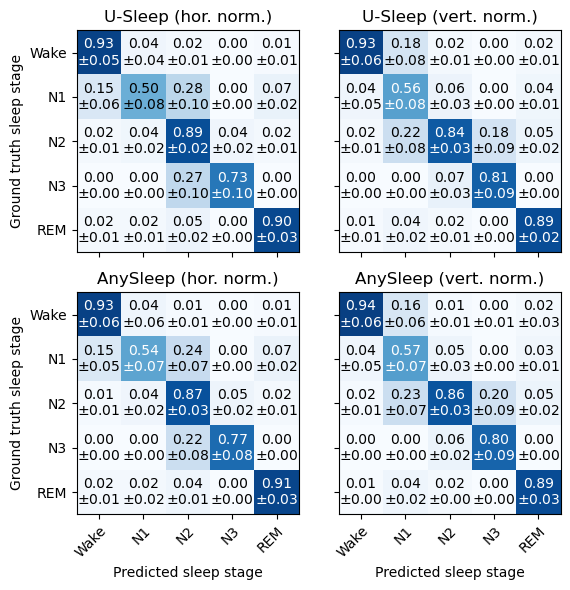

In [12]:
from sklearn.metrics import confusion_matrix

# ID Datasets
_, axes = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
axes = axes.flatten()
cm_usleep = [confusion_matrix(hyp_total_gt_usleep[m][ds], hyp_total_pred_usleep[m][ds], labels=range(5))
             for m in hyp_total_gt_usleep.keys()
             for ds in in_sample_datasets]
cm_usleep_norm_h = [cm / cm.sum(axis=1, keepdims=True) for cm in cm_usleep]
cm_usleep_norm_h_mean = np.mean(cm_usleep_norm_h, axis=0)
cm_usleep_norm_h_std = np.std(cm_usleep_norm_h, axis=0)
cm_usleep_norm_h_text = np.array(
    [[f"{cm_usleep_norm_h_mean[r_i, c_i]:.2f}\n$\pm${cm_usleep_norm_h_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_usleep_norm_h_mean, cm_usleep_norm_h_text, axes[0], "U-Sleep (hor. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))
cm_usleep_norm_v = [cm / cm.sum(axis=0, keepdims=True) for cm in cm_usleep]
cm_usleep_norm_v_mean = np.mean(cm_usleep_norm_v, axis=0)
cm_usleep_norm_v_std = np.std(cm_usleep_norm_v, axis=0)
cm_usleep_norm_v_text = np.array(
    [[f"{cm_usleep_norm_v_mean[r_i, c_i]:.2f}\n$\pm${cm_usleep_norm_v_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_usleep_norm_v_mean, cm_usleep_norm_v_text, axes[1], "U-Sleep (vert. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))

cm_anysleep = [confusion_matrix(hyp_total_gt_anysleep[m][ds], hyp_total_pred_anysleep[m][ds], labels=range(5))
               for m in hyp_total_gt_anysleep.keys()
               for ds in in_sample_datasets]
cm_anysleep_norm_h = [cm / cm.sum(axis=1, keepdims=True) for cm in cm_anysleep]
cm_anysleep_norm_h_mean = np.mean(cm_anysleep_norm_h, axis=0)
cm_anysleep_norm_h_std = np.std(cm_anysleep_norm_h, axis=0)
cm_anysleep_norm_h_text = np.array(
    [[f"{cm_anysleep_norm_h_mean[r_i, c_i]:.2f}\n$\pm${cm_anysleep_norm_h_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_anysleep_norm_h_mean, cm_anysleep_norm_h_text, axes[2], "AnySleep (hor. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))
cm_anysleep_norm_v = [cm / cm.sum(axis=0, keepdims=True) for cm in cm_anysleep]
cm_anysleep_norm_v_mean = np.mean(cm_anysleep_norm_v, axis=0)
cm_anysleep_norm_v_std = np.std(cm_anysleep_norm_v, axis=0)
cm_anysleep_norm_v_text = np.array(
    [[f"{cm_anysleep_norm_v_mean[r_i, c_i]:.2f}\n$\pm${cm_anysleep_norm_v_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_anysleep_norm_v_mean, cm_anysleep_norm_v_text, axes[3], "AnySleep (vert. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))

for ax in [axes[0], axes[2]]:
    ax.set_ylabel("Ground truth sleep stage")
for ax in [axes[2], axes[3]]:
    ax.set_xlabel("Predicted sleep stage")

plt.tight_layout()
plt.savefig("fig_s1a.svg")
plt.show()

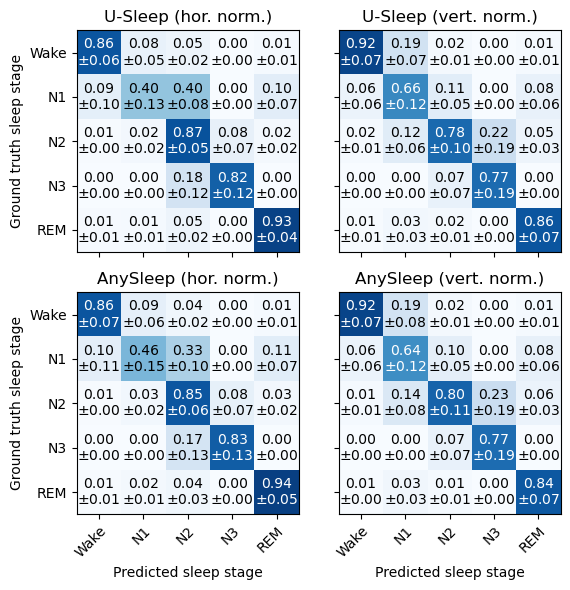

In [13]:
# OOD Datasets
_, axes = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
axes = axes.flatten()
cm_usleep = [confusion_matrix(hyp_total_gt_usleep[m][ds], hyp_total_pred_usleep[m][ds], labels=range(5))
             for m in hyp_total_gt_usleep.keys()
             for ds in ood_datasets]
cm_usleep_norm_h = [cm / cm.sum(axis=1, keepdims=True) for cm in cm_usleep]
cm_usleep_norm_h_mean = np.mean(cm_usleep_norm_h, axis=0)
cm_usleep_norm_h_std = np.std(cm_usleep_norm_h, axis=0)
cm_usleep_norm_h_text = np.array(
    [[f"{cm_usleep_norm_h_mean[r_i, c_i]:.2f}\n$\pm${cm_usleep_norm_h_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_usleep_norm_h_mean, cm_usleep_norm_h_text, axes[0], "U-Sleep (hor. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))
cm_usleep_norm_v = [cm / cm.sum(axis=0, keepdims=True) for cm in cm_usleep]
cm_usleep_norm_v_mean = np.mean(cm_usleep_norm_v, axis=0)
cm_usleep_norm_v_std = np.std(cm_usleep_norm_v, axis=0)
cm_usleep_norm_v_text = np.array(
    [[f"{cm_usleep_norm_v_mean[r_i, c_i]:.2f}\n$\pm${cm_usleep_norm_v_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_usleep_norm_v_mean, cm_usleep_norm_v_text, axes[1], "U-Sleep (vert. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))

cm_anysleep = [confusion_matrix(hyp_total_gt_anysleep[m][ds], hyp_total_pred_anysleep[m][ds], labels=range(5))
               for m in hyp_total_gt_anysleep.keys()
               for ds in ood_datasets]
cm_anysleep_norm_h = [cm / cm.sum(axis=1, keepdims=True) for cm in cm_anysleep]
cm_anysleep_norm_h_mean = np.mean(cm_anysleep_norm_h, axis=0)
cm_anysleep_norm_h_std = np.std(cm_anysleep_norm_h, axis=0)
cm_anysleep_norm_h_text = np.array(
    [[f"{cm_anysleep_norm_h_mean[r_i, c_i]:.2f}\n$\pm${cm_anysleep_norm_h_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_anysleep_norm_h_mean, cm_anysleep_norm_h_text, axes[2], "AnySleep (hor. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))
cm_anysleep_norm_v = [cm / cm.sum(axis=0, keepdims=True) for cm in cm_anysleep]
cm_anysleep_norm_v_mean = np.mean(cm_anysleep_norm_v, axis=0)
cm_anysleep_norm_v_std = np.std(cm_anysleep_norm_v, axis=0)
cm_anysleep_norm_v_text = np.array(
    [[f"{cm_anysleep_norm_v_mean[r_i, c_i]:.2f}\n$\pm${cm_anysleep_norm_v_std[r_i, c_i]:.2f}"
      for c_i in range(5)]
     for r_i in range(5)])
plot_matrix(cm_anysleep_norm_v_mean, cm_anysleep_norm_v_text, axes[3], "AnySleep (vert. norm.)",
            ["Wake", "N1", "N2", "N3", "REM"], col_thresholds=(-1, 0.5))

for ax in [axes[0], axes[2]]:
    ax.set_ylabel("Ground truth sleep stage")
for ax in [axes[2], axes[3]]:
    ax.set_xlabel("Predicted sleep stage")

plt.tight_layout()
plt.savefig("fig_s1b.svg")
plt.show()